In [1]:
%reload_ext autoreload
%autoreload 2

In [13]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0, PROJECT_ROOT)

from utils.config import FREQ_BANDS, BANDS, METRICS, FMAX, ATLAS_PATH
from utils.io.io_atlas import load_atlas
from utils.io.io_results import (
    load_fc_results,
    group_results_by_subject,
    load_fc_combined_data,
    load_groups,
)
from utils.analysis.spectral.marginal_spectrum import build_net_marginals, build_spectral_features_table
from utils.analysis.functional_connectivity.fc_compute import bin_fcs_by_freq
from utils.analysis.functional_connectivity.fc_aggregate_network import aggregate_to_network_fc
from utils.analysis.functional_connectivity.fc_strength import build_fc_strength_df, build_merged_df
from utils.analysis.spectral.ms_statstical_analysis import (run_network_level_tests)
from utils.analysis.spectral.mixed_models import (
    run_subject_level_tests,
    run_mixed_suite_all,
    run_mixed_model_parametric,
    run_all_networks_parametric,
)
from utils.plot.plot_base import set_mpl_style, add_freq_bands
from utils.plot.plot_diagnostics import plot_linearity_check, plot_residual_diagnostics
from utils.plot.plot_ms_results import (
    print_suite_results,
    print_network_summary_table,
    plot_all_networks_summary,
)

sns.set_theme(context="paper", style="white", font_scale=1.0)
set_mpl_style()

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS  (frequency bands, bands list, metrics, etc. come from utils.config)
# ─────────────────────────────────────────────────────────────────────────────

RES_DIR = "/cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/mvmd/fc"

---
## Section 1: Marginal Spectrum Visualization

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — MARGINAL SPECTRUM VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

# Load atlas and subject data
roi_to_net, n_networks, net_names_21 = load_atlas(ATLAS_PATH)
results       = load_fc_results(RES_DIR)
subjects_dict = group_results_by_subject(results)
groups        = load_groups(subjects_dict)

# Compute marginal Hilbert spectra for all subjects and all networks
net_marginals, freqs_ref = build_net_marginals(
    subjects_dict, groups, roi_to_net, n_networks
)

print(f"Loaded {len(subjects_dict)} subjects: "
      f"{sum(g == 'MDD' for g in groups.values())} MDD, "
      f"{sum(g == 'HC' for g in groups.values())} HC")

[Load] Loaded 165 FC result files from /cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/mvmd/fc
Loaded 42 subjects: 21 MDD, 21 HC


In [6]:
# Plot per-network marginal spectra: MDD vs HC
def add_band_labels(ax, fontsize=8):
    """Add frequency band name labels at the top of the axes."""
    for band, (fmin, fmax) in FREQ_BANDS.items():
        if band == "Whole":
            continue
        x = 0.5 * (fmin + fmax)
        ax.text(
            x, 0.98, band,
            transform=ax.get_xaxis_transform(),
            ha="center", va="top",
            fontsize=fontsize, rotation=90,
        )

FIGSIZE = (6.8, 3.2)

# for net_name in net_names_21:
#     net_idx = net_names_21.index(net_name)

#     mdd_arr = np.vstack([H for _, H in net_marginals[net_idx]["MDD"]])
#     hc_arr  = np.vstack([H for _, H in net_marginals[net_idx]["HC"]])

#     mdd_mean = mdd_arr.mean(axis=0)
#     hc_mean  = hc_arr.mean(axis=0)
#     mdd_se   = mdd_arr.std(axis=0, ddof=1) / np.sqrt(mdd_arr.shape[0])
#     hc_se    = hc_arr.std(axis=0, ddof=1) / np.sqrt(hc_arr.shape[0])

#     fig, ax = plt.subplots(figsize=FIGSIZE)
#     add_freq_bands(ax, alpha=0.20)

#     ax.plot(freqs_ref, mdd_mean, label="MDD", color="red")
#     ax.fill_between(freqs_ref, mdd_mean - mdd_se, mdd_mean + mdd_se, color="red", alpha=0.2)
#     ax.plot(freqs_ref, hc_mean, label="HC", color="blue")
#     ax.fill_between(freqs_ref, hc_mean - hc_se, hc_mean + hc_se, color="blue", alpha=0.2)

#     add_band_labels(ax)
#     ax.set_xlim(0.0, FMAX)
#     ax.set_ylim(bottom=0)
#     ax.set_xlabel("Frequency (Hz)")
#     ax.set_ylabel("Marginal amplitude")
#     ax.set_title(f"Marginal Hilbert Spectrum — {net_name}")
#     ax.legend(frameon=False)
#     sns.despine(ax=ax)
#     fig.tight_layout()
#     plt.show()

---
## Section 2: Group Comparison

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — GROUP COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

# Build spectral feature table
df_spec = build_spectral_features_table(
    net_marginals, freqs_ref, FREQ_BANDS, net_names_21
)

# Subject-level permutation tests
# Each value is the median across networks per subject, so subjects are independent.
subject_res = run_subject_level_tests(
    df_spec,
    metrics=[
        "rel_band_amp", "band_entropy", "band_centroid",
        "band_amp", "total_amp", "total_entropy", "total_centroid",
    ],
    bands=BANDS,
    agg="median",
    n_perm=20000,
    seed=1,
)
print("\n=== Subject-level global tests ===")
print(subject_res[[
    "metric", "band", "mean_MDD", "mean_HC", "diff_MDD_minus_HC",
    "p_perm", "q_fdr_metricwise", "cohen_d", "hedges_g", "n_MDD", "n_HC",
]].to_string(index=False, float_format=lambda x: f"{x:.4g}"))


=== Subject-level global tests ===
        metric   band  mean_MDD  mean_HC  diff_MDD_minus_HC  p_perm  q_fdr_metricwise  cohen_d  hedges_g  n_MDD  n_HC
      band_amp Slow-5     18.34    23.02             -4.679  0.0427            0.1396  -0.5398   -0.5297     21    21
      band_amp  Whole     58.49    70.69              -12.2  0.0675            0.1396  -0.4721   -0.4631     21    21
      band_amp Slow-4     28.18    34.15             -5.966 0.08375            0.1396  -0.4336   -0.4255     21    21
      band_amp Slow-2     5.573    5.558            0.01491  0.5048            0.5175 0.003346  0.003283     21    21
      band_amp Slow-3     30.88    30.72             0.1632  0.5175            0.5175  0.01482   0.01454     21    21
 band_centroid Slow-5   0.01971  0.02092          -0.001211  0.0255            0.1275  -0.6247   -0.6129     21    21
 band_centroid Slow-2    0.2157   0.2187          -0.002952  0.1695            0.4237  -0.3027    -0.297     21    21
 band_centroid Slow-

In [8]:
# Network-level permutation tests
# For each (network, band, metric): compare MDD vs HC independently.
# Independence holds: one observation per subject per network (no pooling).
network_res = run_network_level_tests(
    df_spec,
    metrics=["band_amp", "rel_band_amp", "band_centroid"],
    bands=[b for b in BANDS if b != "Whole"],
    n_perm=10000,
    seed=1,
)
significant = network_res[network_res["p_fdr"] < 0.05].sort_values("p_fdr")
print(f"\n=== Network-level tests: {len(significant)} significant results (FDR < 0.05) ===")
if len(significant) > 0:
    print(significant[[
        "network", "metric", "band", "mean_MDD", "mean_HC",
        "diff", "p_perm", "p_fdr", "cohen_d", "hedges_g",
    ]].to_string(index=False, float_format=lambda x: f"{x:.4g}"))
else:
    print("No significant results after FDR correction.")


=== Network-level tests: 0 significant results (FDR < 0.05) ===
No significant results after FDR correction.


---
## Section 3: FC–Amplitude Coupling

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — FC–AMPLITUDE COUPLING
# ─────────────────────────────────────────────────────────────────────────────

# Load combined FC data and prepare frequency-binned matrices
subjects_combined, fcs_by_imf, groups, freqs_by_imf = load_fc_combined_data(RES_DIR)

freq_bands_fc = {k: v for k, v in FREQ_BANDS.items() if k != "Whole"}
fcs_by_band   = bin_fcs_by_freq(subjects_combined, freq_bands_fc)
fcs_by_band["Whole"] = {s: fcs_by_imf["whole"][s] for s in fcs_by_imf["whole"]}
fcs_by_band   = OrderedDict(
    (k, fcs_by_band[k])
    for k in ["Whole", "Slow-5", "Slow-4", "Slow-3", "Slow-2"]
    if k in fcs_by_band
)

binned_netfcs = {
    band: {
        s: aggregate_to_network_fc(fc, roi_to_net, n_networks)
        for s, fc in subj_dict.items()
    }
    for band, subj_dict in fcs_by_band.items()
}

z_binned_netfcs = {
    band: {
        s: np.arctanh(np.clip(fc, -0.999999, 0.999999))
        for s, fc in subj_fcs.items()
    }
    for band, subj_fcs in binned_netfcs.items()
}

df_fc         = build_fc_strength_df(z_binned_netfcs, groups, net_names_21, BANDS)
df_merged_amp = build_merged_df(df_fc, df_spec, "band_amp")

[Load] Loaded 165 FC result files from /cluster/home/herminea/mental_health_project/workspace/results/fmri_prep/mvmd/fc


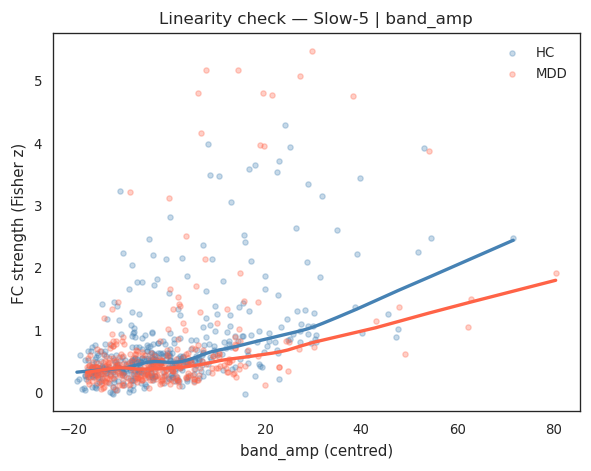

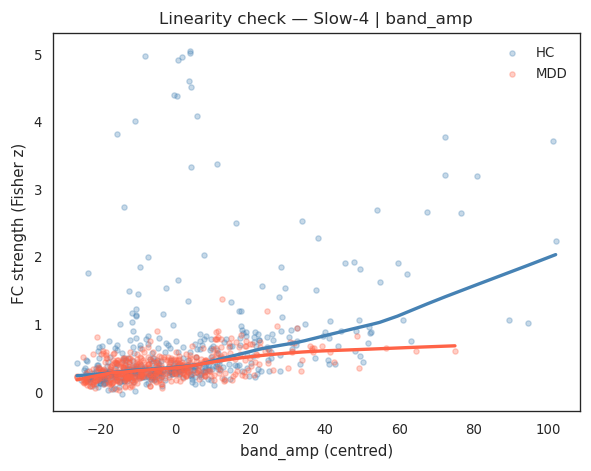

  Fitting band_amp | Slow-5 ...
  Fitting band_amp | Slow-4 ...
  Fitting band_amp | Slow-3 ...
  Fitting band_amp | Slow-2 ...
  Fitting band_amp | Whole ...
  Fitting rel_band_amp | Slow-5 ...
  Fitting rel_band_amp | Slow-4 ...
  Fitting rel_band_amp | Slow-3 ...
  Fitting rel_band_amp | Slow-2 ...
  Fitting rel_band_amp | Whole ...
  Fitting total_amp | Slow-5 ...
  Fitting total_amp | Slow-4 ...
  Fitting total_amp | Slow-3 ...
  Fitting total_amp | Slow-2 ...
  Fitting total_amp | Whole ...

=== Mixed-model suite results ===
      metric   band  n_obs  n_subjects  beta_spec    p_spec  q_fdr_coupling  sig_coupling  beta_group  p_group  beta_group_adj  p_group_adj  beta_interaction  p_interaction  q_fdr_interaction  sig_interaction  AIC_coupling  AIC_additive  AIC_interact
    band_amp Slow-2    567          27    0.02444    0.3809          0.3809         False   -0.001459   0.9712        0.004366       0.8351          0.002183         0.9687             0.9687            False    

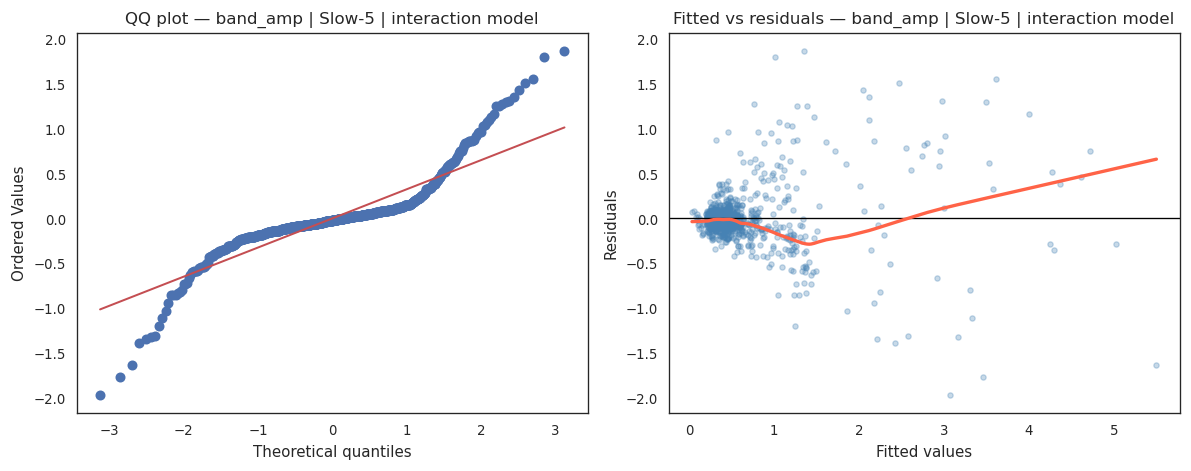


All-network summary | Slow-5 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  SomMotA           1.127   0.000**    -0.001   0.996       0.053   0.918     4118.9       YES
  ContC             0.973   0.001**    -0.029   0.996       0.126   0.918      539.5       YES
  SalVentAttnA      1.544   0.000**    -0.073   0.890       0.049   0.918      167.4       YES
  Striatum          0.418   0.000**    -0.052   0.125*     0.018   0.918      134.4       YES
  TempPar           1.123   0.000**    -0.095   0.888       0.024   0.918      125.7       YES
  ContB             0.588   0.000**    -0.117   0.816      -0.023   0.918       80.5       YES
  DorsAttnB         1.526   0.000**    -0.113   0.961      -0.027   0.922       76.2       YES
  ContA             1.166   0.000**    -0.166   0.816      -0.053   0.918       67.9       YES
  DorsAttnA    

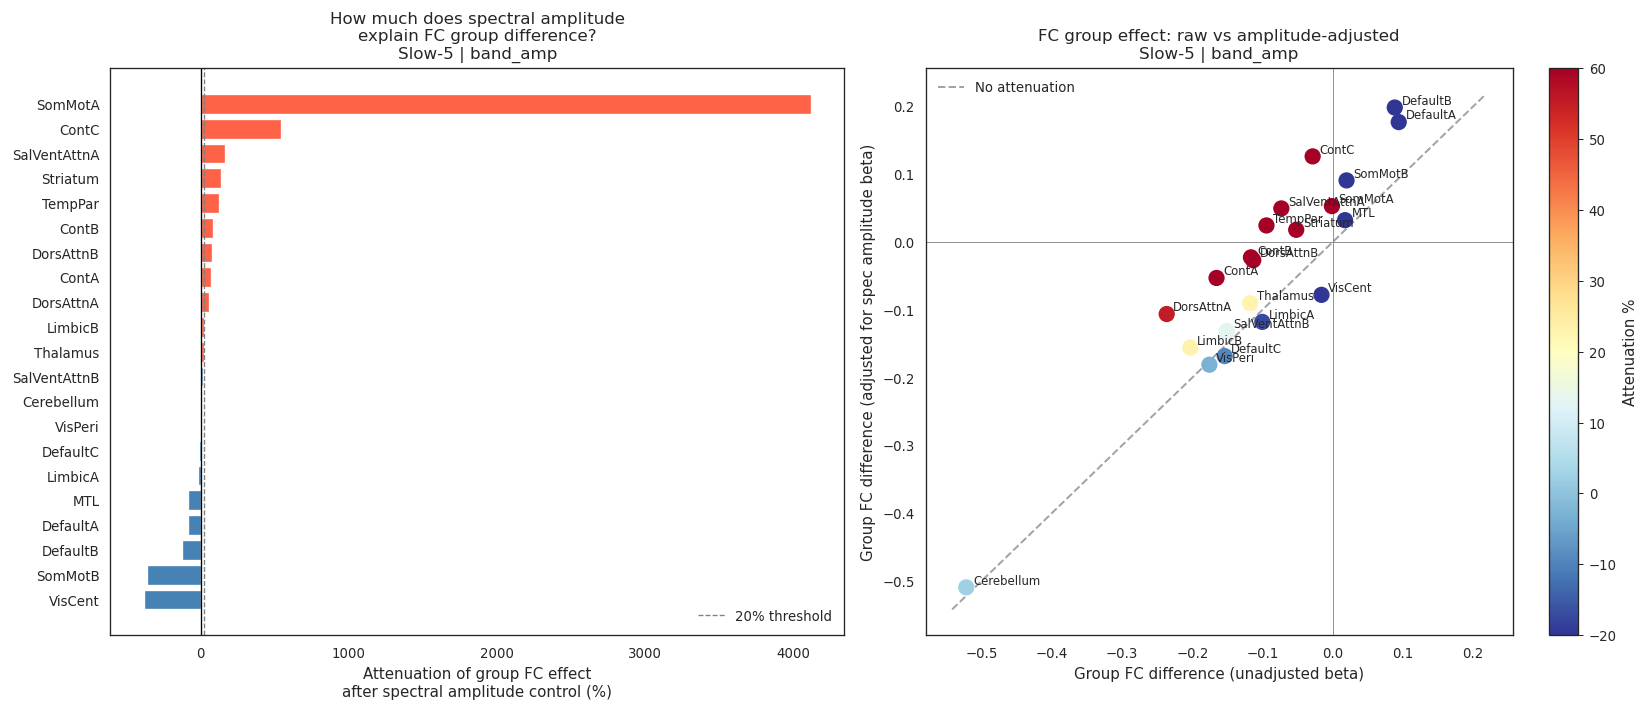


All-network summary | Slow-4 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  Striatum          0.393   0.000**    -0.122   0.012**    -0.047   0.175       61.2       YES
  ContC             0.737   0.000**    -0.318   0.010**    -0.141   0.175       55.7       YES
  DefaultA          0.748   0.000**    -0.210   0.050**    -0.099   0.271       53.1       YES
  ContB             0.756   0.000**    -0.343   0.000**    -0.202   0.072*     41.0       YES
  DefaultC          0.669   0.000**    -0.195   0.000**    -0.115   0.204       40.8       YES
  SomMotB           0.782   0.000**    -0.455   0.074      -0.290   0.173       36.2       YES
  MTL               0.555   0.001**    -0.202   0.238      -0.131   0.438       35.4       YES
  Thalamus          0.792   0.003**    -0.434   0.060*    -0.291   0.173       32.8       YES
  SomMotA       

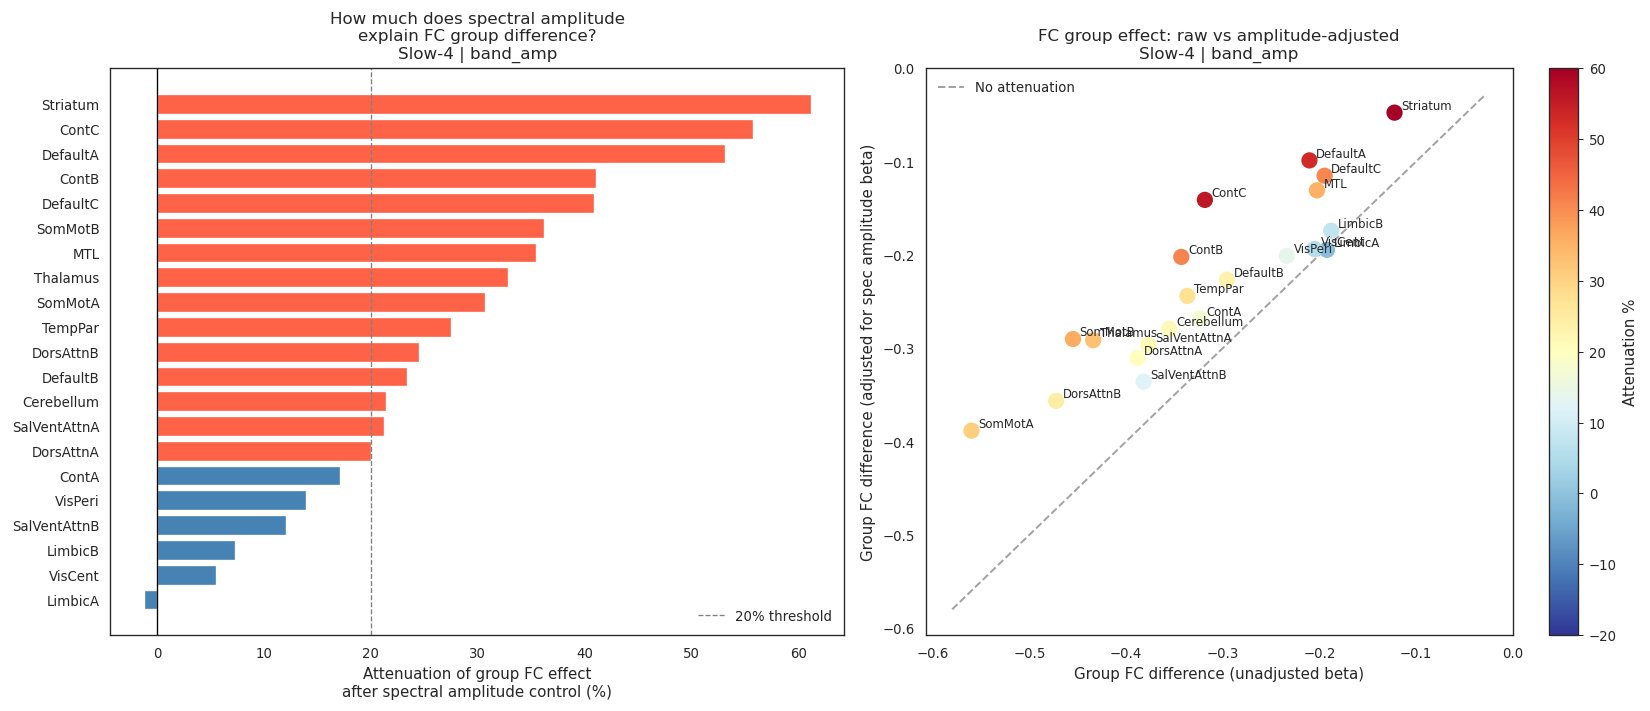


All-network summary | Slow-3 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  Cerebellum        0.667   0.000**     0.105   0.000**     0.006   0.898       93.9       YES
  SalVentAttnB      0.446   0.000**     0.027   0.658       0.006   0.898       77.8       YES
  VisCent           0.438   0.000**     0.083   0.000**     0.052   0.178       37.5       YES
  LimbicA           0.259   0.000**     0.101   0.066*     0.076   0.040**     24.3       YES
  DefaultB          0.354   0.000**     0.050   0.353       0.039   0.415       21.7       YES
  ContA             0.371   0.000**     0.064   0.066*     0.052   0.048**     19.4       YES
  Thalamus          0.378   0.000**     0.036   0.353       0.030   0.309       17.6       YES
  DefaultC          0.393   0.000**     0.076   0.118       0.064   0.205       14.8       YES
  VisPeri       

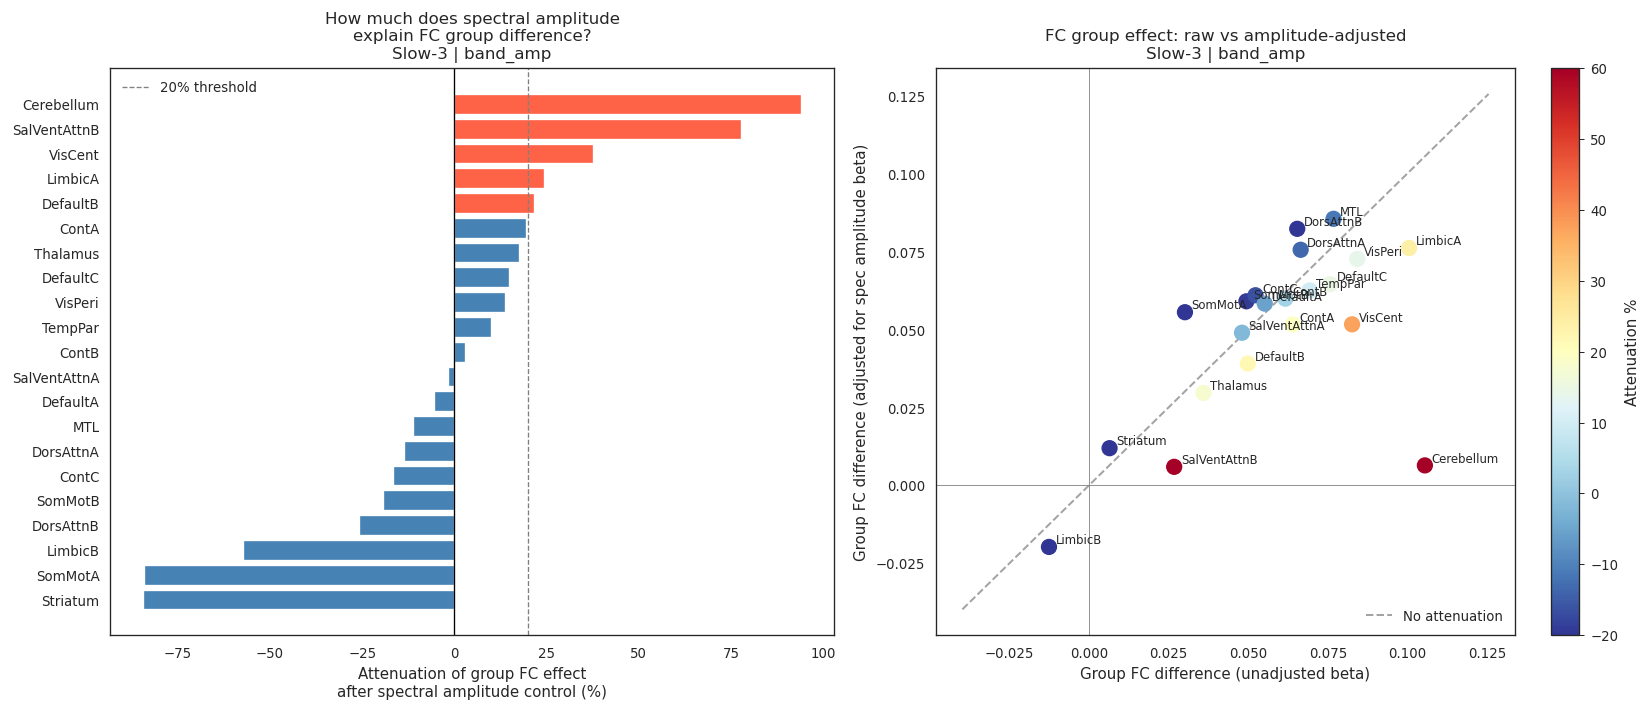


All-network summary | Slow-2 | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  SalVentAttnB      0.249   0.000**    -0.002   0.944       0.016   0.816      783.5       YES
  Thalamus          0.203   0.000**    -0.003   0.944       0.009   0.614      447.6       YES
  SomMotB           0.236   0.000**    -0.005   0.944       0.015   0.816      413.2       YES
  VisPeri           0.264   0.000**    -0.004   0.944       0.006   0.869      249.1       YES
  SomMotA           0.312   0.000**    -0.006   0.944       0.005   0.908      183.1       YES
  ContB             0.217   0.000**    -0.010   0.944       0.007   0.876      166.2       YES
  Cerebellum        0.314   0.000**    -0.009   0.944       0.003   0.875      135.0       YES
  LimbicB           0.091   0.011**    -0.019   0.686      -0.011   0.469       43.1       YES
  VisCent     

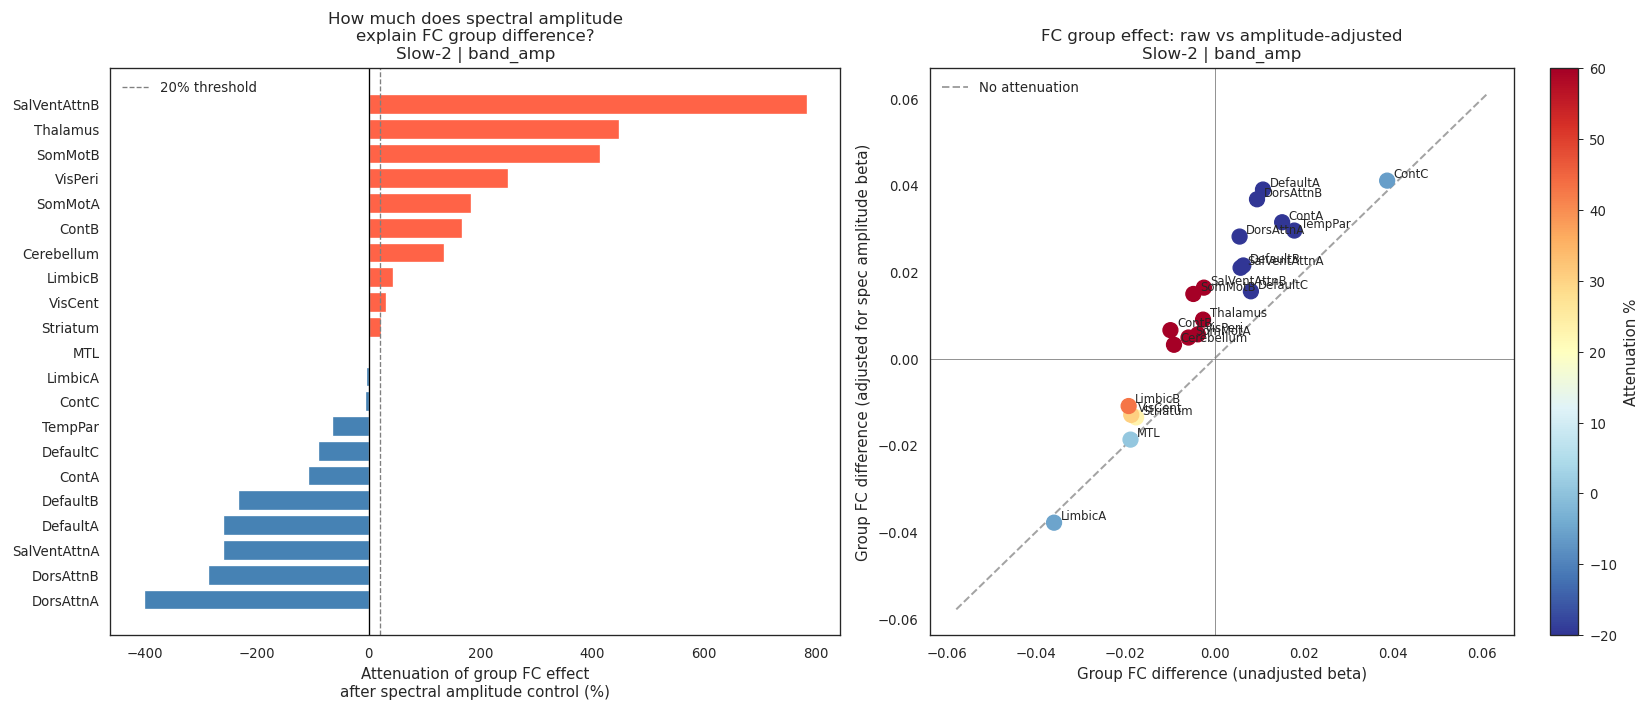


All-network summary | Whole | band_amp
Network         beta_spec   q_spec  beta_grp    q_grp  beta_adj    q_adj   atten%  spec+AIC
--------------------------------------------------------------------------------------------
  Striatum          0.247   0.011**    -0.080   0.057*    -0.040   0.226       50.0       YES
  Thalamus          0.193   0.972      -0.205   0.058*    -0.185   0.001**      9.7        no
  MTL               0.082   0.972      -0.102   0.000**    -0.097   0.121        5.3        no
  SomMotB           0.145   0.972      -0.318   0.113      -0.305   0.153        4.1        no
  SalVentAttnB      0.199   0.972      -0.297   0.140      -0.288   0.108        3.1        no
  Cerebellum        0.112   0.972      -0.318   0.101      -0.313   0.108*      1.8        no
  LimbicA          -0.023   0.972      -0.065   0.017**    -0.064   0.002**      1.4        no
  DefaultC          0.091   0.972      -0.299   0.003**    -0.297   0.108*      0.7        no
  DefaultA         

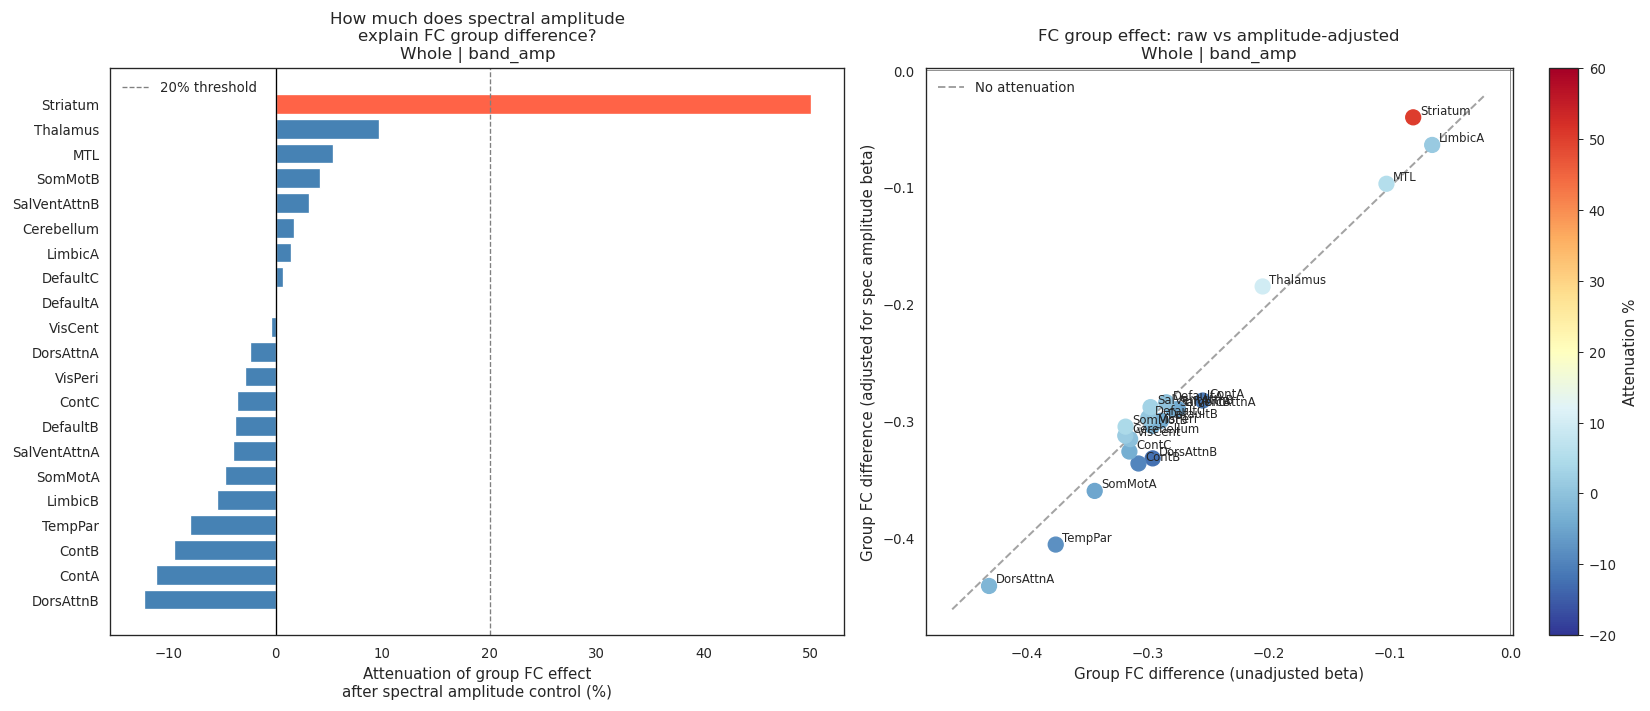

In [14]:
# Linearity checks — always run before fitting parametric models
for band in ["Slow-5", "Slow-4"]:
    plot_linearity_check(df_merged_amp, band=band, metric="band_amp")

# Global mixed model suite (all networks pooled, random intercepts per subject)
df_suite = run_mixed_suite_all(
    df_fc=df_fc,
    df_spec=df_spec,
    metrics=METRICS,
    bands=BANDS,
    control_total_amp=True,
    random_slopes=True,
)
print("\n=== Mixed-model suite results ===")
print_suite_results(df_suite)

# Residual diagnostics on the key Slow-5 interaction model
key = df_suite[
    (df_suite["metric"] == "band_amp") & (df_suite["band"] == "Slow-5")
]
if len(key) > 0:
    plot_residual_diagnostics(
        key.iloc[0]["m_interact"],
        title="band_amp | Slow-5 | interaction model",
    )

# Per-network analysis (independence holds — one row per subject per model)
for band in ["Slow-5", "Slow-4", "Slow-3", "Slow-2", "Whole"]:
    df_net = run_all_networks_parametric(
        df_merged_amp, band=band, metric="band_amp"
    )
    print_network_summary_table(df_net, band=band, metric="band_amp")
    plot_all_networks_summary(df_net, band=band, metric="band_amp")

In [11]:
# Sensitivity check: random slopes on Slow-5 band_amp only
df_merged_amp = build_merged_df(df_fc, df_spec, "band_amp")
row_rs = run_mixed_model_parametric(
    df_merged_amp,
    band="Slow-5",
    metric="band_amp",
    control_total_amp=True,
    random_slopes=True,
)
print(f"beta_group     = {row_rs['beta_group']:.4f}  p = {row_rs['p_group']:.4f}")
print(f"beta_group_adj = {row_rs['beta_group_adj']:.4f}  p = {row_rs['p_group_adj']:.4f}")
print(f"beta_interact  = {row_rs['beta_interaction']:.4f}  p = {row_rs['p_interaction']:.4f}")
print(f"Converged: {row_rs['m_interact'] is not None}")

beta_group     = -0.1002  p = 0.6414
beta_group_adj = -0.1042  p = 0.1592
beta_interact  = 0.0369  p = 0.8068
Converged: True
